# 04. 共役事前分布と事後予測分布 — 紙と鉛筆で解けるベイズ

## この章で分かること

- **共役事前分布**: 事後が事前と同じ族に残る「相性のよいペア」
- 4 つの代表ペア(ベータ×二項・ガンマ×ポアソン・正規×正規・ディリクレ×多項)の **統一的な見方**
- データ量と事前分布の「綱引き」の定量化
- **事後予測分布**: パラメータの不確実性ごと未来を予測する

```{admonition} 核心 — ひとことで
:class: tip
**共役事前とは「尤度と同じ関数形の事前」で、掛けても族が変わらないため更新が "パラメータの足し算" になる。**
4 ペア（ベータ×二項・ガンマ×ポアソン・正規×正規・ディリクレ×多項）すべて、事前＝擬似データ、データが増えれば尤度が勝つ。
**事後予測分布**はパラメータの不確実性を積分で織り込むので、点推定を使うプラグイン予測より広く「正直」。
```

## 1. 共役性とは何か

事前分布 $p(\theta)$ と尤度 $p(x \mid \theta)$ の積が、事前と **同じ分布族** に戻るとき、
その事前を尤度に対する **共役事前分布** と呼びます。

03 章で見たとおり、その本質は「**尤度と事前が $\theta$ について同じ関数形をしている**」こと。
掛けても形が変わらないので、更新は **パラメータの足し算** になります。

| 尤度 | 共役事前 | 更新則(事後のパラメータ) |
|---|---|---|
| ベルヌーイ/二項 | $\mathrm{Beta}(\alpha, \beta)$ | $\alpha + s,\ \beta + f$(成功 $s$ 回・失敗 $f$ 回) |
| ポアソン | $\mathrm{Gamma}(\alpha, \beta)$ | $\alpha + \textstyle\sum_i x_i,\ \beta + n$(総カウントと観測数) |
| 正規(分散既知) | $\mathcal{N}(\mu_0, \tau_0^2)$ | 精度の足し算(下記) |
| 多項 | $\mathrm{Dirichlet}(\boldsymbol{\alpha})$ | $\alpha_k + n_k$(カテゴリ $k$ の回数 $n_k$) |

どのペアも読み方は同じ: **事前 = 擬似データ、更新 = データを足し込む**。

In [1]:
# Shared setup.
import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio
from scipy import stats

from bayes_textbook import visualization as viz
from bayes_textbook.conjugacy import (
    BetaBinomial, DirichletMultinomial, GammaPoisson, NormalNormal,
)
from bayes_textbook.distributions import grid_pdf, simplex_to_xy

pio.renderers.default = "plotly_mimetype+notebook_connected"
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

## 2. ガンマ × ポアソン — 問い合わせ件数のレート推定

**仮説**: コールセンターの 1 日あたり問い合わせ件数のレート $\lambda$。
**事前**: $\lambda \sim \mathrm{Gamma}(\alpha, \beta)$($\alpha$ = 擬似総カウント、$\beta$ = 擬似観測日数)。
**尤度**: $x_i \sim \mathrm{Pois}(\lambda)$。
**事後**: 観測 $n$ 日・総カウント $\sum x_i$ で

$$
\lambda \mid x \sim \mathrm{Gamma}\!\left(\alpha + \textstyle\sum_i x_i,\ \beta + n\right)
$$

daily counts: [8 8 9 7 7 6 5 6 5 4 8 2 6 4]


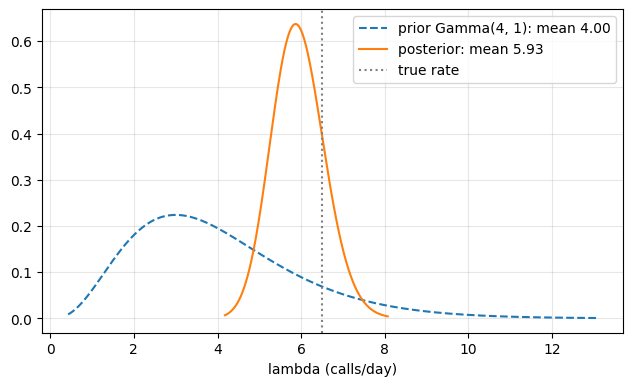

posterior mean = 5.93, 95% CI = [4.76, 7.23]


In [2]:
# Call-center rate: Gamma prior, Poisson data, Gamma posterior.
true_lam = 6.5
counts = rng.poisson(true_lam, size=14)          # two weeks of daily counts
print("daily counts:", counts)

prior = GammaPoisson(4.0, 1.0)                    # weak prior: rate around 4
post = prior.update(int(counts.sum()), len(counts))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for g, name, style in [(prior, "prior Gamma(4, 1)", "--"), (post, "posterior", "-")]:
    x, y = grid_pdf(g.dist)
    ax.plot(x, y, style, label=f"{name}: mean {g.mean:.2f}")
ax.axvline(true_lam, color="gray", ls=":", label="true rate")
ax.set_xlabel("lambda (calls/day)")
ax.grid(alpha=0.3); ax.legend()
plt.show()
lo, hi = post.credible_interval()
print(f"posterior mean = {post.mean:.2f}, 95% CI = [{lo:.2f}, {hi:.2f}]")

## 3. 正規 × 正規 — 平均の推定(分散既知)

**事後の更新は「精度(分散の逆数)の足し算」** です。事前精度 $1/\tau_0^2$、
データ精度 $n/\sigma^2$ として:

$$
\frac{1}{\tau_n^2} = \frac{1}{\tau_0^2} + \frac{n}{\sigma^2},
\qquad
\mu_n = \tau_n^2 \left( \frac{\mu_0}{\tau_0^2} + \frac{\sum_i x_i}{\sigma^2} \right)
$$

事後平均は **事前平均とデータ平均の精度加重平均**。
ここでも「データが増えるとデータ側の重みが勝つ」構図は同じです。

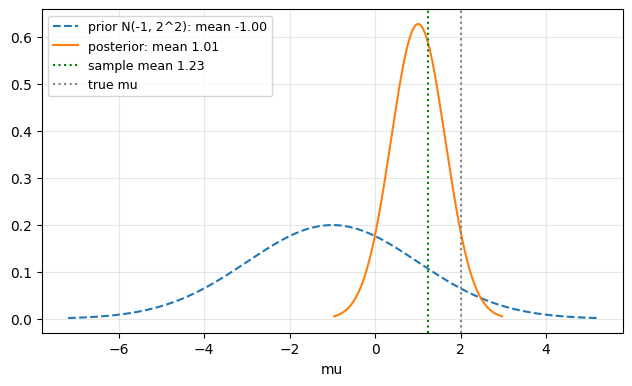

In [3]:
# Normal mean with known sigma: precision-weighted blending.
true_mu, sigma = 2.0, 3.0
data = rng.normal(true_mu, sigma, size=20)

prior = NormalNormal(mu0=-1.0, tau0=2.0, sigma=sigma)   # prior believes mu ~ -1
post = prior.update(data)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
for g, name, style in [(prior, "prior N(-1, 2^2)", "--"), (post, "posterior", "-")]:
    x, y = grid_pdf(g.dist)
    ax.plot(x, y, style, label=f"{name}: mean {g.mean:.2f}")
ax.axvline(data.mean(), color="green", ls=":", label=f"sample mean {data.mean():.2f}")
ax.axvline(true_mu, color="gray", ls=":", label="true mu")
ax.set_xlabel("mu")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.show()

## 4. ディリクレ × 多項 — カテゴリ比率の推定

サイコロの各面の確率や、ユーザーのプラン選択率など。
カテゴリ $k$ を $n_k$ 回観測したら $\alpha_k$ に足すだけです。
3 カテゴリなら事後を単体(三角形)上に描けます。

posterior alpha: (np.float64(49.0), np.float64(33.0), np.float64(11.0))  -> mean: [0.5269 0.3548 0.1183]


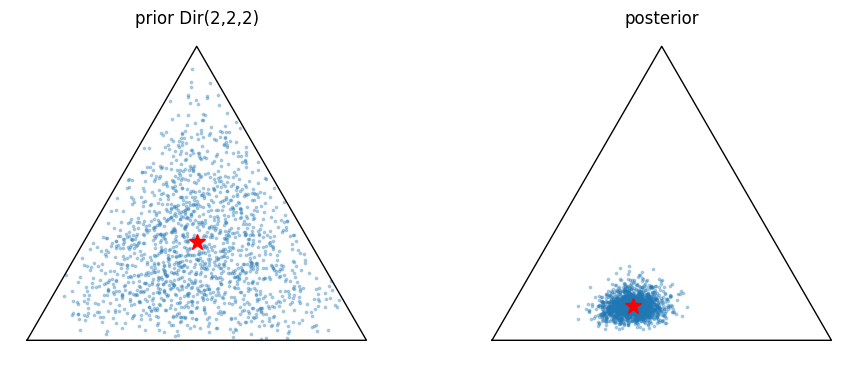

In [4]:
# Plan-choice proportions: Dirichlet prior + multinomial counts.
counts = np.array([47, 31, 9])      # observed choices of plan A / B / C
prior = DirichletMultinomial((2.0, 2.0, 2.0))
post = prior.update(counts)
print("posterior alpha:", post.alpha, " -> mean:", post.mean)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
corners = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2], [0, 0]])
for ax, dm, title in [(axes[0], prior, "prior Dir(2,2,2)"), (axes[1], post, "posterior")]:
    pts = dm.sample(1500, seed=0)
    x, y = simplex_to_xy(pts)
    ax.plot(corners[:, 0], corners[:, 1], "k-", lw=1)
    ax.scatter(x, y, s=3, alpha=0.3)
    mx, my = simplex_to_xy(dm.mean)
    ax.plot(mx, my, "r*", ms=12)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")
plt.show()

## 5. データ量 vs 事前分布 — 綱引きの可視化

すべての共役ペアに共通する構図を、ベータ二項で定量的に見ます。
事後平均のデータ側の重みは $w = n / (\alpha + \beta + n)$ でした(03 章)。
スライダーで $n$ を動かすと、事後が「事前の近く」から「データの近く」へ移っていきます。

In [5]:
# Tug of war: posterior slides from prior toward the data as n grows.
theta = np.linspace(0.001, 0.999, 300)
prior_bb = BetaBinomial(8, 2)          # prior mean 0.8 (optimistic)
data_rate = 0.45                        # the data keep saying 0.45

frames = []
for n in [0, 2, 5, 10, 30, 100, 500]:
    s = int(round(n * data_rate))
    post_bb = prior_bb.update(s, n - s)
    w = n / (prior_bb.alpha + prior_bb.beta + n)
    frames.append((f"n={n} (w={w:.2f})",
                   [("posterior", post_bb.dist.pdf(theta), None),
                    ("prior", prior_bb.dist.pdf(theta), "dash")]))
fig = viz.plotly_curve_slider(theta, frames, slider_name="data size",
                              title="prior mean 0.8 vs data rate 0.45: data wins eventually")
fig.update_xaxes(title="theta")
fig.show()

## 6. 事後予測分布 — 未来の観測を予測する

「次のデータ $x_{\mathrm{new}}$ はどうなるか?」に答えるのが **事後予測分布**:

$$
p(x_{\mathrm{new}} \mid x) = \int p(x_{\mathrm{new}} \mid \theta)\, p(\theta \mid x)\, d\theta
$$

ポイントは **$\theta$ の不確実性を積分で織り込む** こと。
「事後平均を 1 点だけ使った予測(プラグイン予測)」より必ず広くなります。
共役ペアでは予測分布も閉形式です:

| 事後 | 事後予測分布 |
|---|---|
| ベータ | ベータ二項分布 |
| ガンマ | 負の二項分布 |
| 正規 | 正規($\sigma^2 + \tau_n^2$ に分散が膨らむ) |

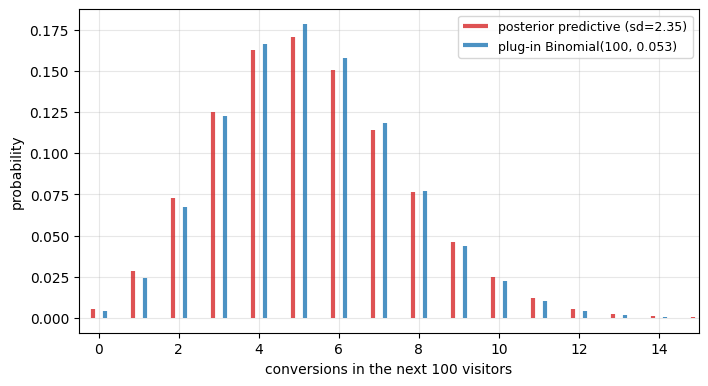

In [6]:
# Posterior predictive vs plug-in: the predictive is wider (theta uncertainty).
cvr_post = BetaBinomial(1, 1).update(52, 948)        # the ch.03 CVR example
n_new = 100                                          # next 100 visitors

k, pp_pmf = cvr_post.posterior_predictive(n_new)
plug_in = stats.binom(n_new, cvr_post.mean).pmf(k)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.vlines(k - 0.15, 0, pp_pmf, lw=3, alpha=0.8, color="#d62728",
          label=f"posterior predictive (sd={np.sqrt(np.sum(pp_pmf*(k-np.sum(k*pp_pmf))**2)):.2f})")
ax.vlines(k + 0.15, 0, plug_in, lw=3, alpha=0.8, color="#1f77b4",
          label=f"plug-in Binomial(100, {cvr_post.mean:.3f})")
ax.set_xlim(-0.5, 15)
ax.set_xlabel("conversions in the next 100 visitors")
ax.set_ylabel("probability")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.show()

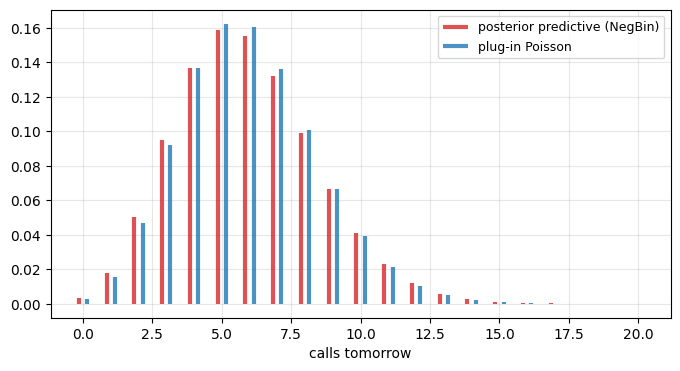

predictive variance > plug-in variance: True


In [7]:
# Same idea for the call center: Negative Binomial predictive for tomorrow's count.
post_rate = GammaPoisson(4.0, 1.0).update(int(rng.poisson(6.5, 14).sum()), 14)
k, pp = post_rate.posterior_predictive(k_max=20)
plug = stats.poisson(post_rate.mean).pmf(k)

fig, ax = plt.subplots(figsize=(8, 4))
ax.vlines(k - 0.15, 0, pp, lw=3, alpha=0.8, color="#d62728", label="posterior predictive (NegBin)")
ax.vlines(k + 0.15, 0, plug, lw=3, alpha=0.8, color="#1f77b4", label="plug-in Poisson")
ax.set_xlabel("calls tomorrow")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.show()
print("predictive variance > plug-in variance:",
      float(np.sum(pp * k**2) - np.sum(pp * k)**2) > float(np.sum(plug * k**2) - np.sum(plug * k)**2))

予測の分散が膨らむ分だけ「正直」です。
**自分のパラメータ推定がまだ甘いことを、予測自身が知っている** — これが事後予測分布の価値です。

## 7. Failure Mode — 共役性の限界

- 共役で済むのは **モデルが単純な間だけ**。回帰の係数が増えたり、階層化したり、
  リンク関数が入った瞬間に閉形式は消えます(→ 07 章 MCMC、08 章 PyMC)。
- 共役事前は「計算が楽」なだけで「正しい」わけではない。
  ドメイン知識と矛盾する共役事前を使うくらいなら、非共役 + MCMC の方が誠実。
- 正規×正規は **分散既知** の仮定が強い。分散も未知なら逆ガンマ/Student-t の世界
  (本書では 08 章で PyMC に任せます)。

## 8. まとめ

- 共役性 = 尤度と事前が同じ関数形 → 更新がパラメータの足し算になる。
- 4 ペア共通の読み方: **事前は擬似データ、データ量が増えれば必ず尤度が勝つ**。
- **事後予測分布** はパラメータの不確実性を積分で織り込む。プラグイン予測より広く、正直。
- 閉形式が使える範囲は狭い。だが「答えの形」を知る基準点として、後の章でも検算に使い続ける。

## 9. Exercises

1. ガンマ×ポアソンで、事前 $\mathrm{Gamma}(2, 0.5)$・観測 5 日で計 40 件のとき、
   事後分布と 95% 信用区間を求めよ。
2. 正規×正規の事後平均が「精度加重平均」であることを、$n = 1$ の場合に式で確認し、
   数値でも検算せよ。
3. ディリクレ×多項で、カテゴリ 3 つの観測 (47, 31, 9) に対し
   「プラン A の選択率が 50% を超える確率」をサンプリングで求めよ。
4. ベータ二項の事後予測分布(§6)で、$n$ を 10 倍にしたとき
   予測分布とプラグイン予測の差がどう縮むか確認せよ。
5. (発展)$p(x_{\mathrm{new}} \mid x)$ の積分を、ベータ事後からのモンテカルロ
   ($\theta$ を引いて二項を引く)で近似し、`posterior_predictive` の閉形式と比較せよ。

```{admonition} 実社会では
:class: important
共役ペアは「素早く事後を出す」基準点で、予測分布は在庫・需要計画に直結します。

- レート推定：問い合わせ・故障・到着件数 → ガンマ×ポアソン、平均値 → 正規×正規。
- 事後予測（負の二項・ベータ二項）：「明日の件数」「次の 100 人の成約数」を不確実性ごと予測 → 安全在庫・人員計画。
- 限界も明確：回帰・階層・リンク関数が入ると閉形式は消える → MCMC / PyMC（07・08 章）。
```